## Klasifikasi Data Menggunakan metode K-Nearest Neighbor (KNN)

algoritma supervised learning (Sudah Ada Jawaban / Labelnya)

### Import Lib

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Read Data Set

In [44]:
df_balance = pd.read_csv('balance-scale.csv') #baca data

In [45]:
df_balance #tampilin data

,Class,L-Weight,L-Distance,R-Weight,R-Distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5
...,...,...,...,...,...
620,L,5,5,5,1
621,L,5,5,5,2
622,L,5,5,5,3
623,L,5,5,5,4


In [46]:
df_balance.info() #membaca info data

<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Class       625 non-null    str  
 1   L-Weight    625 non-null    int64
 2   L-Distance  625 non-null    int64
 3   R-Weight    625 non-null    int64
 4   R-Distance  625 non-null    int64
dtypes: int64(4), str(1)
memory usage: 24.5 KB


In [47]:
df_balance.describe() #melihat rata rata max min data

,L-Weight,L-Distance,R-Weight,R-Distance
count,625.000000,625.000000,625.000000,625.000000
mean,3.000000,3.000000,3.000000,3.000000
std,1.415346,1.415346,1.415346,1.415346
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [48]:
pd.unique(df_balance['Class']) #membaca nilai uniq data

<StringArray>
['B', 'R', 'L']
Length: 3, dtype: str

In [49]:
df_balance['Class'].value_counts() # melihat banyak nya data per uniq data

Class
R    288
L    288
B     49
Name: count, dtype: int64

### Split Data Set

In [50]:
x = df_balance.iloc[:, 1:].values 
x

# .iloc → indexing berdasarkan posisi (integer), bukan nama kolom
# [:, 1:] → ada dua bagian dipisah koma:
# : (sebelum koma) → ambil semua baris
# 1: (setelah koma) → ambil kolom mulai dari index 1 sampai akhir 
# (skip kolom pertama / index 0)

array([[1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 3],
       ...,
       [5, 5, 5, 3],
       [5, 5, 5, 4],
       [5, 5, 5, 5]], shape=(625, 4))

In [51]:
y = df_balance.iloc[:,[0]]
y
# Kebalikannya dari tadi — df_balance.iloc[:, [0]] itu ambil hanya kolom pertama (index 0).

,Class
0,B
1,R
2,R
3,R
4,R
...,...
620,L
621,L
622,L
623,L


In [52]:
y = y.values.reshape(len(y),)

### Feature Scalling

In [53]:
from sklearn.preprocessing import MinMaxScaler

In [54]:
Scaller = MinMaxScaler()

In [55]:
x= Scaller.fit_transform(x)

### Split Train Test

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=0)

### Klasfikasi

In [58]:
from sklearn.neighbors import KNeighborsClassifier

### Train Dan Fit

train uji <br>
fit belajar

In [59]:
Data_1 = KNeighborsClassifier(n_neighbors= 21, metric='euclidean').fit(x_train, y_train)
Data_1


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Prediksi

In [60]:
y_prediksi = Data_1.predict(x_test)

In [61]:
y_prediksi

array(['L', 'R', 'L', 'R', 'L', 'R', 'L', 'L', 'R', 'R', 'R', 'R', 'R',
       'L', 'R', 'L', 'L', 'L', 'L', 'L', 'L', 'R', 'R', 'L', 'L', 'L',
       'L', 'L', 'R', 'R', 'L', 'L', 'R', 'L', 'R', 'L', 'L', 'L', 'R',
       'R', 'L', 'L', 'L', 'L', 'L', 'L', 'L', 'R', 'R', 'R', 'R', 'R',
       'L', 'L', 'R', 'R', 'R', 'L', 'L', 'L', 'L', 'R', 'L', 'L', 'L',
       'L', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L', 'L', 'R', 'L', 'L',
       'L', 'R', 'R', 'R', 'L', 'R', 'L', 'R', 'L', 'L', 'L', 'R', 'L',
       'L', 'L', 'R', 'R', 'L', 'L', 'L', 'R', 'R', 'R', 'L', 'L', 'R',
       'L', 'R', 'L', 'L', 'R', 'L', 'R', 'R', 'L', 'R', 'L', 'R', 'L',
       'L', 'R', 'R', 'L', 'R', 'L', 'L', 'R'], dtype=object)

### Cek Akurasi & Evaluasi

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
print("Nilai Akurasi : ", accuracy_score(y_test, y_prediksi))

Nilai Akurasi :  0.944


Text(50.722222222222214, 0.5, 'PREKDIKSI (y_prekdiksi)')

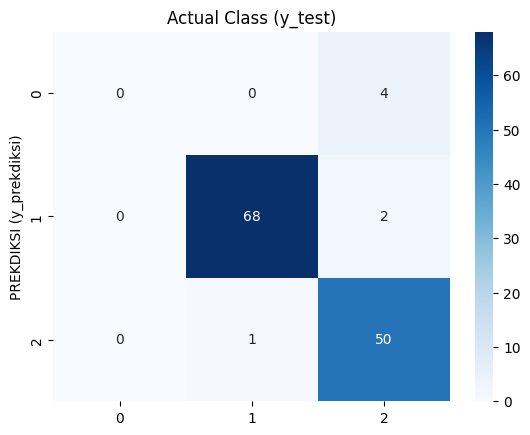

In [64]:
cm = confusion_matrix(y_test, y_prediksi)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Actual Class (y_test)")
plt.ylabel("PREKDIKSI (y_prekdiksi)")

In [65]:
print("confusion metrix : ", confusion_matrix(y_test, y_prediksi))


confusion metrix :  [[ 0  0  4]
 [ 0 68  2]
 [ 0  1 50]]


### Mencari Nilai K terbaik

In [66]:
n_akurasi= []
for k in range (1,30):
    Data_1 = KNeighborsClassifier(n_neighbors= k, metric='euclidean').fit(x_train, y_train)
    y_prediksi = Data_1.predict(x_test)
    akurasi = accuracy_score(y_test, y_prediksi)
    n_akurasi.append(akurasi)
print(n_akurasi)
    

[0.752, 0.744, 0.784, 0.768, 0.824, 0.832, 0.856, 0.88, 0.904, 0.904, 0.92, 0.912, 0.936, 0.936, 0.936, 0.928, 0.912, 0.928, 0.928, 0.936, 0.944, 0.936, 0.936, 0.928, 0.92, 0.92, 0.928, 0.928, 0.928]


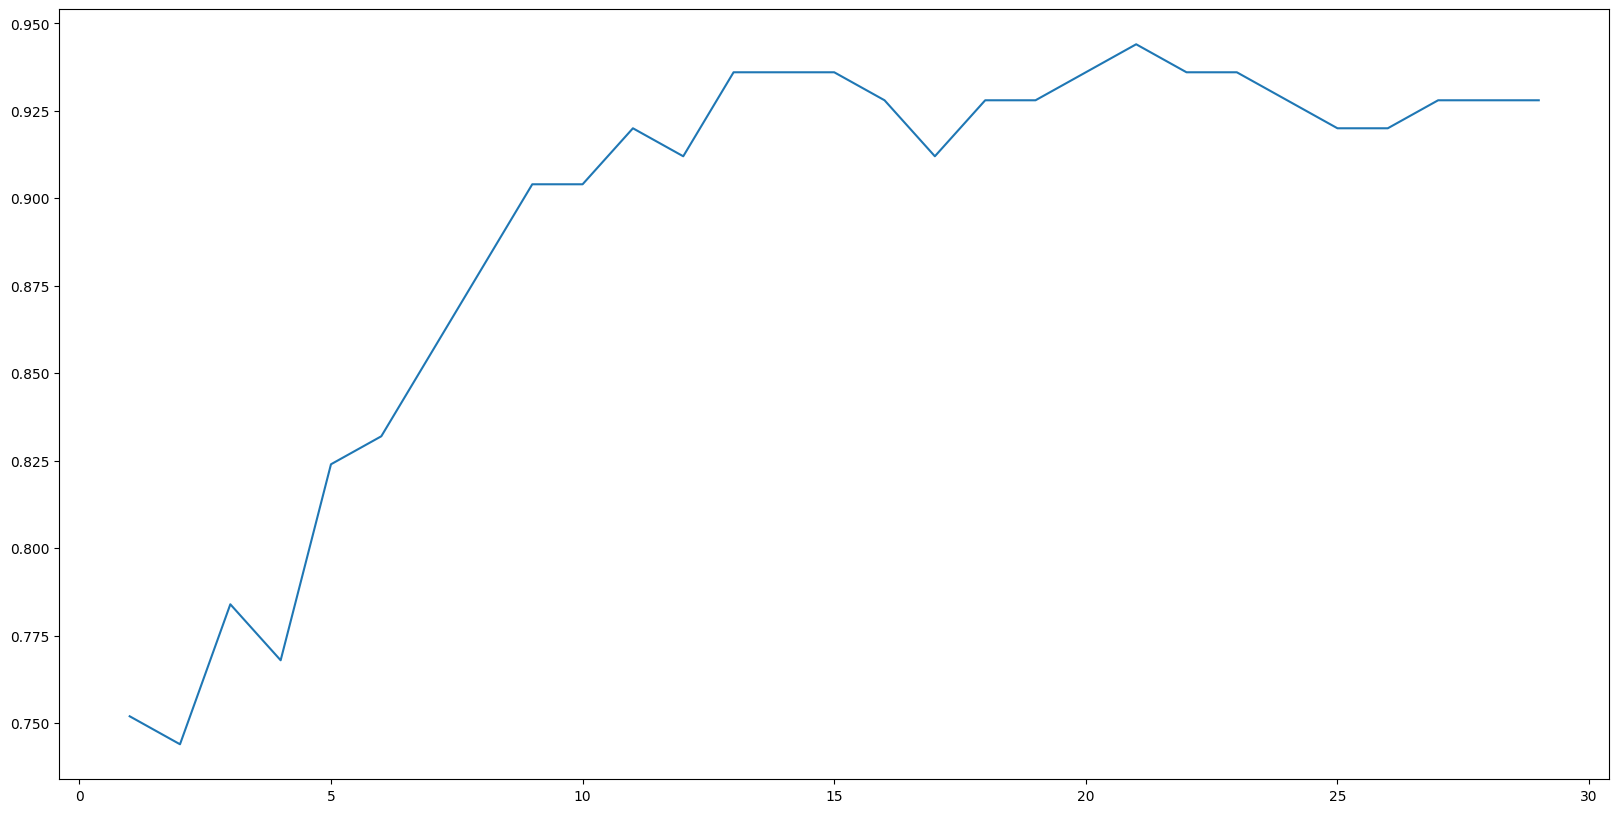

In [67]:
plt.figure(figsize=(20,10))
plt.plot(range(1,30), n_akurasi)
plt.show()

In [68]:
n_akurasi

[0.752,
 0.744,
 0.784,
 0.768,
 0.824,
 0.832,
 0.856,
 0.88,
 0.904,
 0.904,
 0.92,
 0.912,
 0.936,
 0.936,
 0.936,
 0.928,
 0.912,
 0.928,
 0.928,
 0.936,
 0.944,
 0.936,
 0.936,
 0.928,
 0.92,
 0.92,
 0.928,
 0.928,
 0.928]

### Klasifikasi Data Baru

In [72]:
newData = [[4,3,2,1]]
new_prediksi = Data_1.predict(newData)
print(new_prediksi)

['L']
